<font size=10>**GENERAL DATA PREPROCESSING**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

<u>Text Structure</u> + <u>Vocabulary</u>

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Text Structure](#3)
- [4. General Text Preprocessing](#4)
- [5. Vocabulary](#5)
- [6. Non-English Reviews - Detection and Translation](#6)
- [7. Feature Extraction](#7)
    - [7.1 TF-IDF](#7_1)
    - [7.2 Counter](#7_2)
- [8. Visualizations](#8)
    - [8.1 Categories](#8_1)
    - [8.2 Ratings](#8_2)
    

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [95]:
# pip install deep-translator
# pip install langdetect
# pip install langid

In [120]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
import sys
import os
import pandas as pd

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from general_preprocessing import *
from visualizations import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [4]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [5]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [6]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [7]:
dataset = dataset_original.copy()

In [8]:
# keep a fixed example
dataset['text'].sample(1, random_state=12).values

array(['Had my hubby\'s 75th Birthday at McKendrick\'s, and it was absolutely FABULOUS!! as is dinner, there ALWAYS!! Yepper it\'s always great, all the time..you can\'t say that about many places in Atlanta.The food is excellent, no matter what you order..and it\'s Just Classy! Carol was just the best, she helped us plan the menu as well as how much we needed... just a doll. And Brian was great getting all the details down pat. If your looking for a fantastic waiter, you can\'t go wrong with Dave Harper, Dobbs, or"MIKE the waiter"..all of them are first class and funny! Thank You McKendrick\'s for making this nite, so special! And Happy New Year to you all!'],
      dtype=object)

# <font color='#BFD72F' size=6>**3. Text Structure**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

In [9]:
# TODO: See how many sentences do we have in the 'review_text' column
dataset['num_sentences'] = dataset['text'].apply(lambda x: len(str(x).split('. ')))

In [10]:
dataset['num_sentences'].describe()

count    53566.000000
mean         2.783071
std          2.657222
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         43.000000
Name: num_sentences, dtype: float64

In [11]:
histogram_chart(
    data=dataset,
    column='num_sentences',
    title='Number of Sentences per Review',
    x_label='Number of Sentences'
)

# <font color='#BFD72F' size=6>**4. General Text Preprocessing**</font> <a class="anchor" id="4"></a>
  
[Back to TOC](#toc)

1. **Clean data** - remove extraneous content.

2. **Transform data** - tokenization, POS tagging, stopwords removal.

3. **Normalize data** - case, stemming, and lemmatization.


*NOTE*:

It is better to tokenize first and then remove punctuation, as some punctuation marks may be part of words (e.g., "don't", "it's").
This way, we can preserve the integrity of words while still removing unwanted punctuation.

In [12]:
# 1️⃣ CLEAN DATA — remove extraneous content
dataset['01_cleaned_text'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=False,              # we’ll remove them later
        stopwords_tokeep=['again'],
        extra_stopwords=[],
        convert_diacritics=True,
        lowercase=False,                 # normalization step later
        lemmatized=False,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )
)

In [13]:
# 2️⃣ TRANSFORM DATA — tokenization, POS tagging, stopwords removal
dataset['02_transformed_text'] = dataset['01_cleaned_text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=True,
        stopwords_tokeep=['again'],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=['n', 'v', 'a', 'r', 's'],
        stemmed=False,
        pos_tags_list='pos',
        tokenized_output=True,
        no_emojis=False,
        no_hashtags=False,
        hashtag_retain_words=True,
        no_newlines=False,
        no_urls=False,
        no_punctuation=False,
        treat_repeated_chars=False
    )
)

In [68]:
# POS tags for each review (aligned with 02_transformed_text tokens)
dataset["pos_tags"] = dataset["02_transformed_text"].apply(
    lambda tokens: nltk.pos_tag(tokens) if isinstance(tokens, (list, tuple)) else []
)

dataset["pos_tags"].head()

0    [(One, CD), (word, NN), (amazing, NN), (red, J...
1    [(First, JJ), (time, NN), (food, NN), (great, ...
2    [(recently, RB), (pleasure, NN), (dining, VBG)...
3    [(Beautiful, NNP), (atmosphere, RB), (deliciou...
4    [(wonderful, JJ), (dinner, NN), (Optimist, NNP...
Name: pos_tags, dtype: object

In [14]:
# 3️⃣ NORMALIZE DATA — case normalization, stemming, lemmatization
dataset['03_normalized_text'] = dataset['02_transformed_text'].apply(
    lambda x: main_pipeline(
        raw_text=' '.join(x) if isinstance(x, list) else x,
        no_stopwords=False,              # already removed
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=True,
        list_pos=['n', 'v', 'a', 'r', 's'],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=True,
        no_emojis=False,
        no_hashtags=False,
        hashtag_retain_words=True,
        no_newlines=False,
        no_urls=False,
        no_punctuation=False,
        treat_repeated_chars=False
    )
)

In [15]:
# Follow an example

print("Original Text Sample:\n")
print(dataset[['text']].sample(1, random_state=12).values)

print("\nCleaned Text Sample:\n")
print(dataset[['01_cleaned_text']].sample(1, random_state=12).values)

print("\nTransformed Text Sample:\n")
print(dataset[['02_transformed_text']].sample(1, random_state=12).values)

print("\nNormalized Text Sample:\n")
print(dataset[['03_normalized_text']].sample(1, random_state=12).values)


Original Text Sample:

[['Had my hubby\'s 75th Birthday at McKendrick\'s, and it was absolutely FABULOUS!! as is dinner, there ALWAYS!! Yepper it\'s always great, all the time..you can\'t say that about many places in Atlanta.The food is excellent, no matter what you order..and it\'s Just Classy! Carol was just the best, she helped us plan the menu as well as how much we needed... just a doll. And Brian was great getting all the details down pat. If your looking for a fantastic waiter, you can\'t go wrong with Dave Harper, Dobbs, or"MIKE the waiter"..all of them are first class and funny! Thank You McKendrick\'s for making this nite, so special! And Happy New Year to you all!']]

Cleaned Text Sample:

[['Had my hubbys 75th Birthday at McKendricks and it was absolutely FABULOUS as is dinner there ALWAYS Yepper its always great all the cant say that about many places in AtlantaThe food is excellent no matter what you its Just Classy Carol was just the best she helped us plan the menu as 

In [16]:
dataset['token_count'] = dataset['02_transformed_text'].apply(len)

histogram_chart(
    data=dataset,
    column='token_count',
    title='Token Count per Review',
    x_label='Number of Tokens'
)

In [17]:
dataset['review_char_len'] = dataset['text'].astype(str).str.len()

histogram_chart(
    data=dataset,
    column='review_char_len',
    title='Review Length (Characters)',
    x_label='Number of Characters'
)

# <font color='#BFD72F' size=6>**5. Vocabulary**</font> <a class="anchor" id="5"></a>
  
[Back to TOC](#toc)

In [18]:
corpus = dataset['03_normalized_text'].explode()
print(f'Corpus Size: {len(corpus)}')
corpus

Corpus Size: 966130


0          one
0         word
0        amaze
0          red
0         fish
         ...  
53565    space
53565    table
53565     live
53565    music
53565     back
Name: 03_normalized_text, Length: 966130, dtype: object

In [19]:
vocabulary = corpus.unique()
print(f'Vocabulary Size: {len(vocabulary)}')
vocabulary

Vocabulary Size: 25378


array(['one', 'word', 'amaze', ..., 'tartufo', 'ryleigh', 'francaise'],
      shape=(25378,), dtype=object)

# <font color='#BFD72F' size=6>**6. Non-English Reviews - Detection and Translation**</font> <a class="anchor" id="6"></a>
  
[Back to TOC](#toc)

trying to use txt blob

In [20]:
# Extract non-English reviews
non_english_reviews_langdetect = extract_non_english_reviews_langdetect(dataset, text_column="text")

# Preview results
print(non_english_reviews_langdetect)

      index                                       text language
0        57                             Simply amazing       hu
1        69                             Food was good.       so
2        89                                       Rico       pt
3       133  Decent home made pasta... No surprises :)       pt
4       154                            Amazing brunch!       de
...     ...                                        ...      ...
3613  53368                                 L O ve IT!       pt
3614  53376             Great spot in Marietta Square.       it
3615  53469  Jordan was awesome! We had a great night.       af
3616  53539                          Jordan was great.       af
3617  53559                        Jordan was amazing!       id

[3618 rows x 3 columns]


In [21]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [22]:
! pip install textblob
python -m textblob.download_corpora


SyntaxError: invalid syntax (3949924266.py, line 2)

In [23]:
from textblob import TextBlob

b = TextBlob("bonjour")
# Detect the language
language = b.detect_language()
print(language)  # Output: 'fr'


AttributeError: 'TextBlob' object has no attribute 'detect_language'

with google


In [24]:
## in terminal: 
# pip install googletrans==4.0.0-rc1

In [26]:
from googletrans import Translator

translator = Translator()
 # Output: 'fr'
for review in dataset['text'].sample(5, random_state=4).values:
    lang = translator.detect(review).lang
    print(f'Review: {review}\nDetected Language: {lang}\n') 

dataset['language'] = dataset['text'].apply(lambda x: translator.detect(x).lang)

Review: Paolg was a great waisters. She gave amazing recommendation to eat
Detected Language: en

Review: the best margaritas!!
Thanks to Mateo the waiter, the experience was incredible, and Manager Mireya
Detected Language: en

Review: ARBY's
Detected Language: en

Review: I thoroughly enjoyed my whole experience. Food was fire and Kenny was great. Very friendly and I just soaked the vibe. I totally fan girled being there, since I have watched Kandi and the Gang, Real Housewives of Atlanta, and listened to Xscape back in the day. Love love love and I would love to come back and try all the things.
Detected Language: en

Review: Amazing staff. Order here all the time. Fresh food. And everything they make is amazing. I love their curry and lard Kai. Definitely a place to check out.
Detected Language: en



AttributeError: 'Translator' object has no attribute 'raise_Exception'

In [18]:
for review in dataset['text'].sample(5, random_state=12).values:
    lang = translator.detect(review).lang
    print(f'Review: {review}\nDetected Language: {lang}\n') 

NameError: name 'dataset' is not defined

In [ ]:
#! pip install polyglot
#! pip install icu

In [1]:
pip install fasttext


  Using cached fasttext-0.9.3.tar.gz (73 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for fasttext (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [57 lines of output]
      /private/var/folders/pw/hnfxgj5143jcn5jfg4mgf6zm0000gn/T/pip-build-env-pnpqmqsc/overlay/lib/python3.10/site-packages/setuptools/dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please 

In [3]:
import fasttext
ft_model = fasttext.load_model("/Users/maria/Library/CloudStorage/OneDrive-NOVAIMS/terceiro_ano/text_mining/project/Text_Mining---Atlanta_Reviews/lid.176.bin")

In [4]:
# Source - https://stackoverflow.com/a
# Posted by Rabash, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-10, License - CC BY-SA 4.0

import fasttext
model = fasttext.load_model("/Users/maria/Library/CloudStorage/OneDrive-NOVAIMS/terceiro_ano/text_mining/project/Text_Mining---Atlanta_Reviews/lid.176.bin")
print(model.predict('الشمس تشرق', k=2))  # top 2 matching languages

(('__label__ar', '__label__fa'), array([0.98124713, 0.01265871]))


ValueError: Unable to avoid copy while creating an array as requested.
If using `np.array(obj, copy=False)` replace it with `np.asarray(obj)` to allow a copy when needed (no behavior change in NumPy 1.x).
For more details, see https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword.

In [38]:
# Source - https://stackoverflow.com/a
# Posted by Rabash, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-10, License - CC BY-SA 4.0

from polyglot.detect import Detector

mixed_text = u"""
China (simplified Chinese: 中国; traditional Chinese: 中國),
officially the People's Republic of China (PRC), is a sovereign state
located in East Asia.
"""
for language in Detector(mixed_text).languages:
        print(language)

# name: English     code: en       confidence:  87.0 read bytes:  1154
# name: Chinese     code: zh_Hant  confidence:   5.0 read bytes:  1755
# name: un          code: un       confidence:   0.0 read bytes:     0


ImportError: cannot import name 'Locale' from 'icu' (/Users/maria/anaconda3/envs/text_mining/lib/python3.10/site-packages/icu/__init__.py)

In [27]:
non_english_reviews_langid = extract_non_english_reviews_langid(dataset, text_column="text")
non_english_reviews_langid

,index,text,language
0,81,Amazing food intimate dinning space FANTASTIC ...,it
1,99,Always excellent! Great place!,de
2,130,Old school Italian restaurant....great service...,it
3,133,Decent home made pasta... No surprises :),lt
4,155,mas de media hora en la barra para que los bar...,es
...,...,...,...
2898,53397,Delicious!,es
2899,53398,Great food Great entertainment,da
2900,53446,Excellent food!,de
2901,53529,"Delicious Food, Spacious Dining Space!",es


In [28]:
def translate_to_english(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except Exception:
        return text  # fallback if translation fails
en_df= dataset[["text"]]
print(en_df)
en_df["translated_text"] = en_df["text"].apply(translate_to_english)

                                                    text
0      One word amazing!! The red fish,  halibut,  fr...
1      First time here and the food is great and the ...
2      I recently had the pleasure of dining at Optim...
3      Beautiful atmosphere and delicious food. All o...
4      We had a wonderful dinner at the Optimist. Our...
...                                                  ...
53561  Friday night dinner was Chicken Francaise. Jor...
53562                 Great dinner.... Yay  Jordan!!!!!!
53563  Jordan was our server and he was fantastic! Gr...
53564  Jordan was an amazing server!  Great delicious...
53565  Great food and service.   Well spaced tables a...

[53566 rows x 1 columns]


KeyboardInterrupt: 

In [ ]:

non_english = extract_non_english_reviews_langdetect(en_df, text_column="translated_text")

# Preview results
print(non_english)

      index                            translated_text language
0        57                             Simply amazing       hu
1        69                             Food was good.       so
2        89                                       Rico       pt
3       133  Decent home made pasta... No surprises :)       pt
4       154                            Amazing brunch!       de
...     ...                                        ...      ...
3613  53368                                 L O ve IT!       pt
3614  53376             Great spot in Marietta Square.       it
3615  53469  Jordan was awesome! We had a great night.       af
3616  53539                          Jordan was great.       af
3617  53559                        Jordan was amazing!       id

[3618 rows x 3 columns]


In [56]:
en_df.iloc[155]

text               mas de media hora en la barra para que los bar...
translated_text    mas de media hora en la barra para que los bar...
Name: 155, dtype: object

In [35]:
#pd.set_option("display.max_rows", None)
#pd.reset_option("display.max_rows")

# <font color='#BFD72F' size=6>**7. Feature Extraction**</font> <a class="anchor" id="7"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>7.1 TF-IDF</font> <a class="anchor" id="7_1"></a>
  
[Back to TOC](#toc)

In [25]:
tfidf_text, tfidf_vectorizer = vectorize_texts(dataset['03_normalized_text'])
tfidf_df = pd.DataFrame(tfidf_text.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [26]:
tfidf_df.sample(1, random_state=12)

,10,100,1010,12,15,1st,20,25,30,40,...,yes,yesterday,yet,york,youll,young,youre,yum,yummy,zero
11414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
tfidf_means = tfidf_df.mean(axis=0).sort_values(ascending=False).head(20)
tfidf_top_df = pd.DataFrame({
    'token': tfidf_means.index,
    'tfidf_weight': tfidf_means.values
})
bar_chart(
    data=tfidf_top_df,
    x='token',
    y='tfidf_weight',
    title='Top 20 tokens by TF-IDF weight',
    labels={'token': 'Token', 'tfidf_weight': 'Average TF-IDF Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds/tfidf_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x167b978c0>}

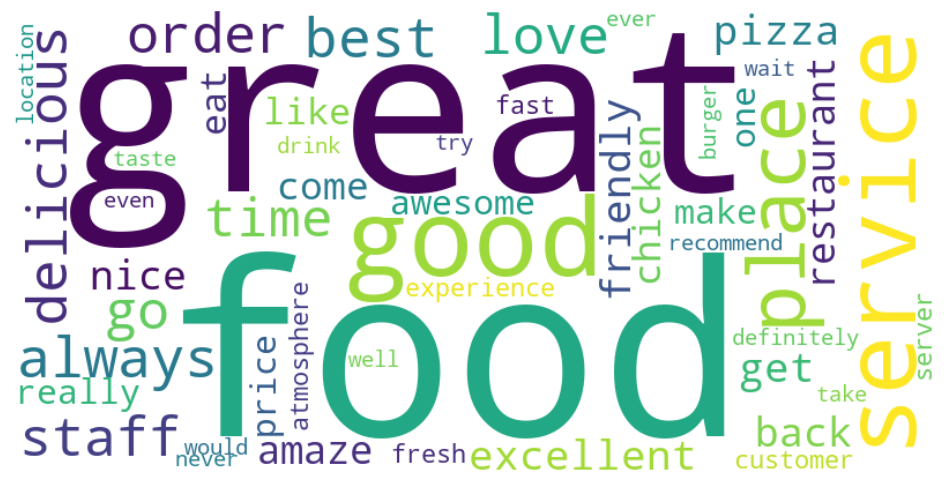

In [28]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='tfidf_vectorization.png',
    vectorized_df=tfidf_df,
    top_n=50
)

In [29]:
cooc_matrix_tfidf = cooccurrence_matrix(tfidf_df, sentence_cooc=False, window_size=5)

Computing co-occurrences: 100%|██████████| 53566/53566 [00:05<00:00, 10506.92it/s]


In [30]:
display(cooc_matrix_tfidf)

,food,good,service,order,go,great,get,time,place,back,...,que,un,ashley,en,servicio,lugar,atencion,buena,excelente,buen
food,0,8243,9505,3293,3923,8660,3413,3653,4311,3177,...,7,17,34,12,5,2,2,1,6,2
good,8243,0,4835,2156,2346,3250,2313,2246,2728,1813,...,5,8,12,2,0,0,2,1,4,1
service,9505,4835,0,1948,2241,6248,1929,2192,2288,2004,...,8,9,37,7,6,2,2,0,5,1
order,3293,2156,1948,0,2163,1291,2391,2156,1727,1484,...,6,6,3,4,1,1,0,0,0,0
go,3923,2346,2241,2163,0,1846,2098,2122,2009,2267,...,4,3,13,4,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lugar,2,0,2,1,1,0,0,1,3,1,...,39,46,0,36,31,0,21,16,40,33
atencion,2,2,2,0,0,1,0,1,0,0,...,23,19,0,20,17,21,0,55,42,14
buena,1,1,0,0,0,1,0,1,0,0,...,20,19,0,25,26,16,55,0,21,20
excelente,6,4,5,0,1,1,0,0,1,1,...,20,29,0,20,57,40,42,21,0,17


## <font color='#BFD72F' size=6>7.2 Counter</font> <a class="anchor" id="7_2"></a>
  
[Back to TOC](#toc)

In [31]:
counter_text, counter_vectorizer = vectorize_texts(
    dataset['03_normalized_text'], vectorizer_type='count'
)
counter_df = pd.DataFrame(counter_text.toarray(), columns=counter_vectorizer.get_feature_names_out())

In [32]:
counter_df.sample(1, random_state=12)

,10,100,1010,12,15,1st,20,25,30,40,...,yes,yesterday,yet,york,youll,young,youre,yum,yummy,zero
11414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
counter_means = counter_df.mean(axis=0).sort_values(ascending=False).head(20)
counter_top_df = pd.DataFrame({
    'token': counter_means.index,
    'counter_weight': counter_means.values
})
bar_chart(
    data=counter_top_df,
    x='token',
    y='counter_weight',
    title='Top 20 tokens by Counter weight',
    labels={'token': 'Token', 'counter_weight': 'Average Counter Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds/counter_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x1631e3890>}

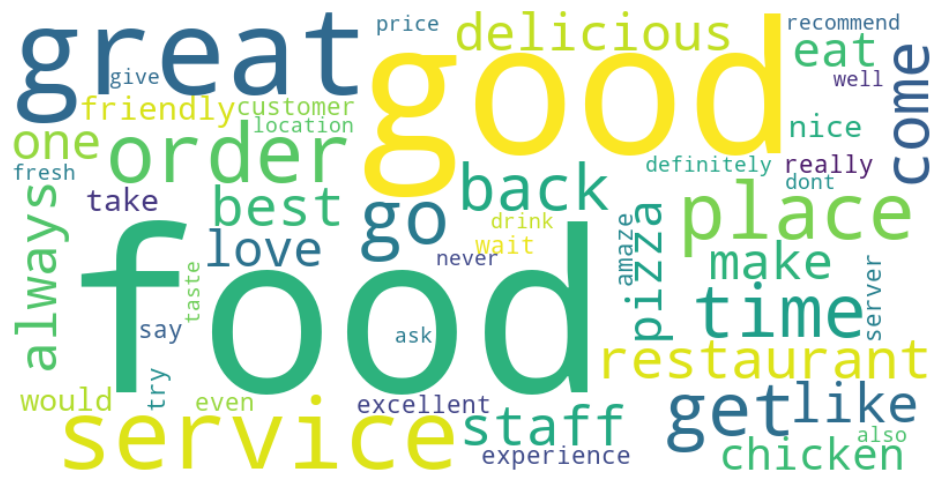

In [34]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='counter_vectorization.png',
    vectorized_df=counter_df,
    top_n=50
)

# <font color='#BFD72F' size=6>**8. Visualizations**</font> <a class="anchor" id="8"></a>
  
[Back to TOC](#toc)

**WEEK 04**

**Word Clouds** for quick visual exploration:  
- **Size →** word frequency (the bigger, the more frequent)  
- **Color →** can encode:  
  - Part of speech (noun, adjective, verb)  
  - Sentiment (e.g., red for negative, green for positive)  

**Bar Charts**  
- General keyword frequencies  
- Keywords per rating  

**Pie Charts**  
- Group by noun/adjective/verb  
- Group by rating  

**Tree Maps**  
- Group by noun/adjective/verb  
- Group by rating  

**Circle Charts**  
- Color words by sentiment intensity (color scale)  

**Network Graphs**  
- Identify clusters and relationships (color by cluster)  

**Heatmaps**  
- Correlation of features, sentiment vs. score, etc.

**Horizontal Bar Chart**
- O que o stor costuma usar para ver o tfidf nas aulas, todo colorido.


## <font color='#BFD72F' size=6>8.1 Categories</font> <a class="anchor" id="8_1"></a>
  
[Back to TOC](#toc)

In [35]:
tfidf_df = pd.DataFrame(
    tfidf_text.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df['categoryName'] = dataset['categoryName'].values

tfidf_cat_mean = tfidf_df.groupby('categoryName').mean(numeric_only=True)

no_rows = 3  # ----> Arbitrário
cats_to_plot = (
    tfidf_df['categoryName']
    .value_counts()
    .head(no_rows)
    .index
    .tolist()
)

for cat in cats_to_plot:
    top = (
        tfidf_cat_mean.loc[cat]
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
        .rename(columns={'index': 'token', cat: 'mean_tfidf'})
    )
    bar_chart(
        data=top,
        x='token',
        y='mean_tfidf',
        title=f"{cat} - Top 10 tokens by TF-IDF weight",
        labels={'token': 'Token', 'mean_tfidf': 'TF-IDF weight'},
        top_n=10
    )


## <font color='#BFD72F' size=6>8.2 Ratings</font> <a class="anchor" id="8_2"></a>
  
[Back to TOC](#toc)

In [36]:
tfidf_df = pd.DataFrame(
    tfidf_text.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df['stars'] = pd.to_numeric(dataset['stars'])

tfidf_df = tfidf_df[tfidf_df['stars'].between(1, 5, inclusive='both')].copy()

tfidf_star_mean = tfidf_df.groupby('stars').mean(numeric_only=True).sort_index()

TOP_N = 10  # ---> Arbitrário
for star in tfidf_star_mean.index:
    top = (
        tfidf_star_mean.loc[star]
        .sort_values(ascending=False)
        .head(TOP_N)
        .reset_index()
        .rename(columns={'index': 'token', star: 'mean_tfidf'})
    )
    bar_chart(
        data=top,
        x='token',
        y='mean_tfidf',
        title=f"{int(star)}★ - Top {TOP_N} tokens by TF-IDF weight",
        labels={'token': 'Token', 'mean_tfidf': 'TF-IDF weight'},
        top_n=TOP_N
    )

## <font color='#BFD72F' size=6>8.3 Word Clouds</font> <a class="anchor" id="8_3"></a>
  
[Back to TOC](#toc)

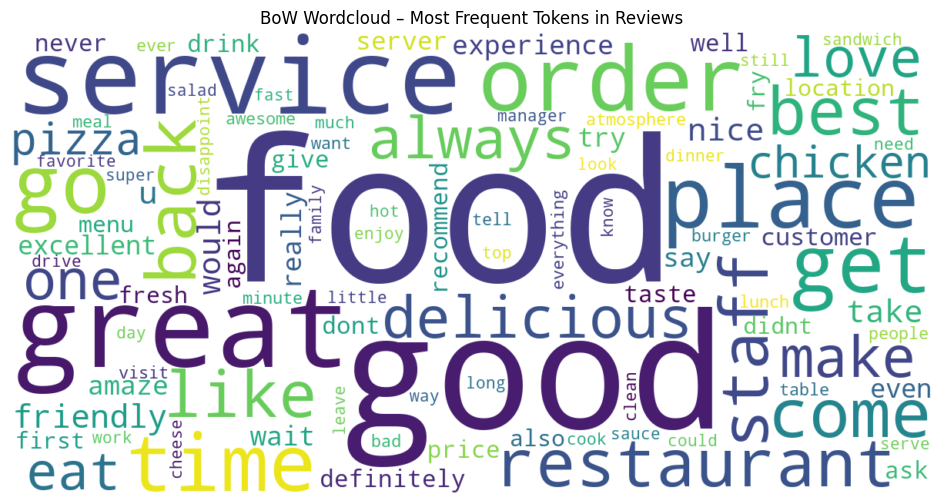

In [60]:
wordcloud_from_tokens(
    dataset["03_normalized_text"],
    max_words=100,
    title="BoW Wordcloud – Most Frequent Tokens in Reviews"
)

#### 8.3.1 Wordcloud coloured by rating


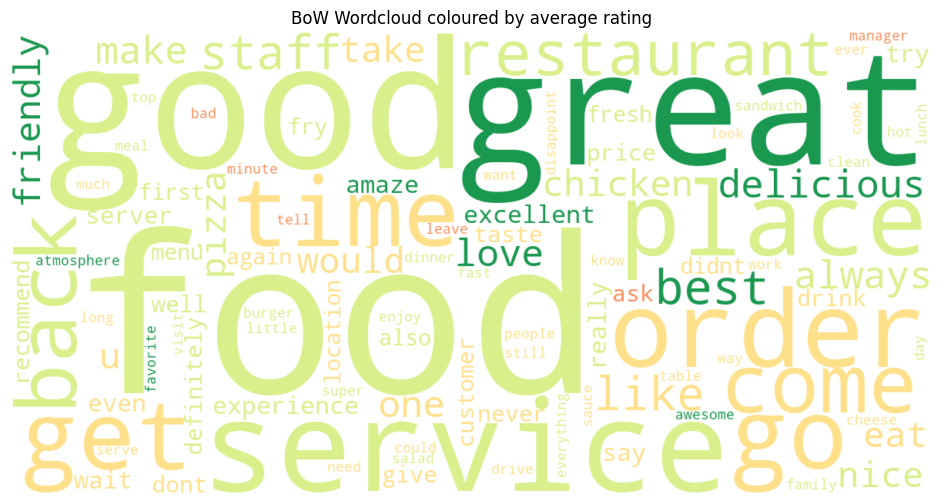

In [65]:
wordcloud_by_rating(
    token_series=dataset["03_normalized_text"],
    ratings_series=dataset["stars"],   
    max_words=100,
    title="BoW Wordcloud coloured by average rating"
)

### 8.3.2 Wordcloud coloured by Part-of-Speech (POS)



In [71]:
# Turn list of (word, tag) tuples into just a list of tags
dataset["pos_tags_simple"] = dataset["pos_tags"].apply(
    lambda sent: [tag for (_, tag) in sent] if isinstance(sent, (list, tuple)) else []
)

dataset["pos_tags_simple"].head()


0    [CD, NN, NN, JJ, NN, NN, VBD, NN, NN, NNS, VBP...
1                             [JJ, NN, NN, JJ, NN, NN]
2    [RB, NN, VBG, NNP, NNP, NNP, VB, VB, VB, JJ, N...
3    [NNP, RB, JJ, NN, NN, NN, JJ, JJ, NN, JJ, NNS,...
4          [JJ, NN, NNP, NN, CD, JJ, NN, NNS, VBP, JJ]
Name: pos_tags_simple, dtype: object

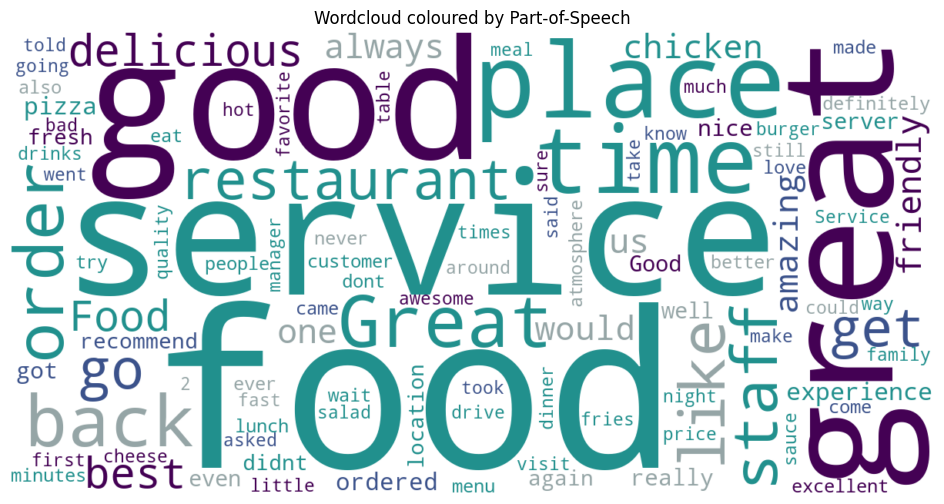

In [81]:
wc_pos = wordcloud_by_pos(
    token_series=dataset["02_transformed_text"],
    pos_series=dataset["pos_tags_simple"],   # use the simple tags
    max_words=100,
    title="Wordcloud coloured by Part-of-Speech"
)


## <font color='#BFD72F' size=6>8.4 Tree Maps</font> <a class="anchor" id="8_4"></a>
  
[Back to TOC](#toc)


In [90]:

# Convert tokens → strings
processed = dataset["03_normalized_text"].apply(
    lambda x: " ".join(x) if isinstance(x, (list, tuple)) else str(x)
)

# Reuse same CountVectorizer your function uses
vectorizer = CountVectorizer(stop_words="english")
bow_matrix = vectorizer.fit_transform(processed)

# Convert to DataFrame
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Sum frequencies
token_freq = bow_df.sum(axis=0).sort_values(ascending=False)

# Keep only TOP N
token_freq_df = (
    pd.DataFrame({
        "token": token_freq.index,
        "frequency": token_freq.values
    })
    .head(TOP_N)
    .reset_index(drop=True)
)

token_freq_df.head()

,token,frequency
0,food,28712
1,good,18016
2,great,17999
3,service,15829
4,order,10821


In [103]:
TOP_N = 100  # or whatever number you want (e.g., 50)

# token_freq_df already exists from the cell above
token_freq_df = token_freq_df.head(TOP_N)

# Treemap
treemap_chart(
    data=token_freq_df,
    path_col=["token"],       # hierarchical path — simple (1 level)
    value_col="frequency",    # size of each tile
    title=f"Treetmap of Top {TOP_N} Most Frequent Words (BoW)"
)


### 8.4.1 Tree Map by POS

In [107]:
pos_token_df = build_pos_token_freq(
    dataset["03_normalized_text"],
    dataset["pos_tags_simple"]      # use the cleaned POS tags
)

pos_token_df.head()


,pos,token,frequency
4581,NOUN,food,28698
4629,NOUN,service,15699
23473,ADJ,good,15345
23428,ADJ,great,12490
4638,NOUN,place,9278


In [108]:
TOP_N = 100
pos_token_top = pos_token_df.head(TOP_N)


In [109]:
treemap_chart(
    data=pos_token_top,
    path_col=["pos", "token"],     # hierarchy: POS → word
    value_col="frequency",
    title=f"Treemap of Top {TOP_N} Words by POS"
)


In [114]:
cooc_df = build_cooccurrence_matrix_tokens(
    dataset["03_normalized_text"],   # your token column
    top_n=200                        # use 200 for strong visualizations
)

cooc_df.head()


,food,good,great,service,order,place,go,get,time,back,...,inside,wrong,authentic,italian,keep,item,im,wont,overall,old
food,0,8243,8660,9505,3293,4311,3923,3413,3653,3177,...,464,411,597,481,512,445,421,457,547,438
good,8243,0,3250,4835,2156,2728,2346,2313,2246,1813,...,308,240,246,244,326,277,288,306,475,286
great,8660,3250,0,6247,1291,2709,1846,1483,1869,1696,...,206,139,272,274,283,199,183,181,341,209
service,9505,4835,6247,0,1948,2288,2241,1929,2192,2004,...,249,256,238,240,335,255,236,251,356,240
order,3293,2156,1291,1948,0,1727,2163,2391,2156,1484,...,305,511,98,110,290,359,282,291,266,266


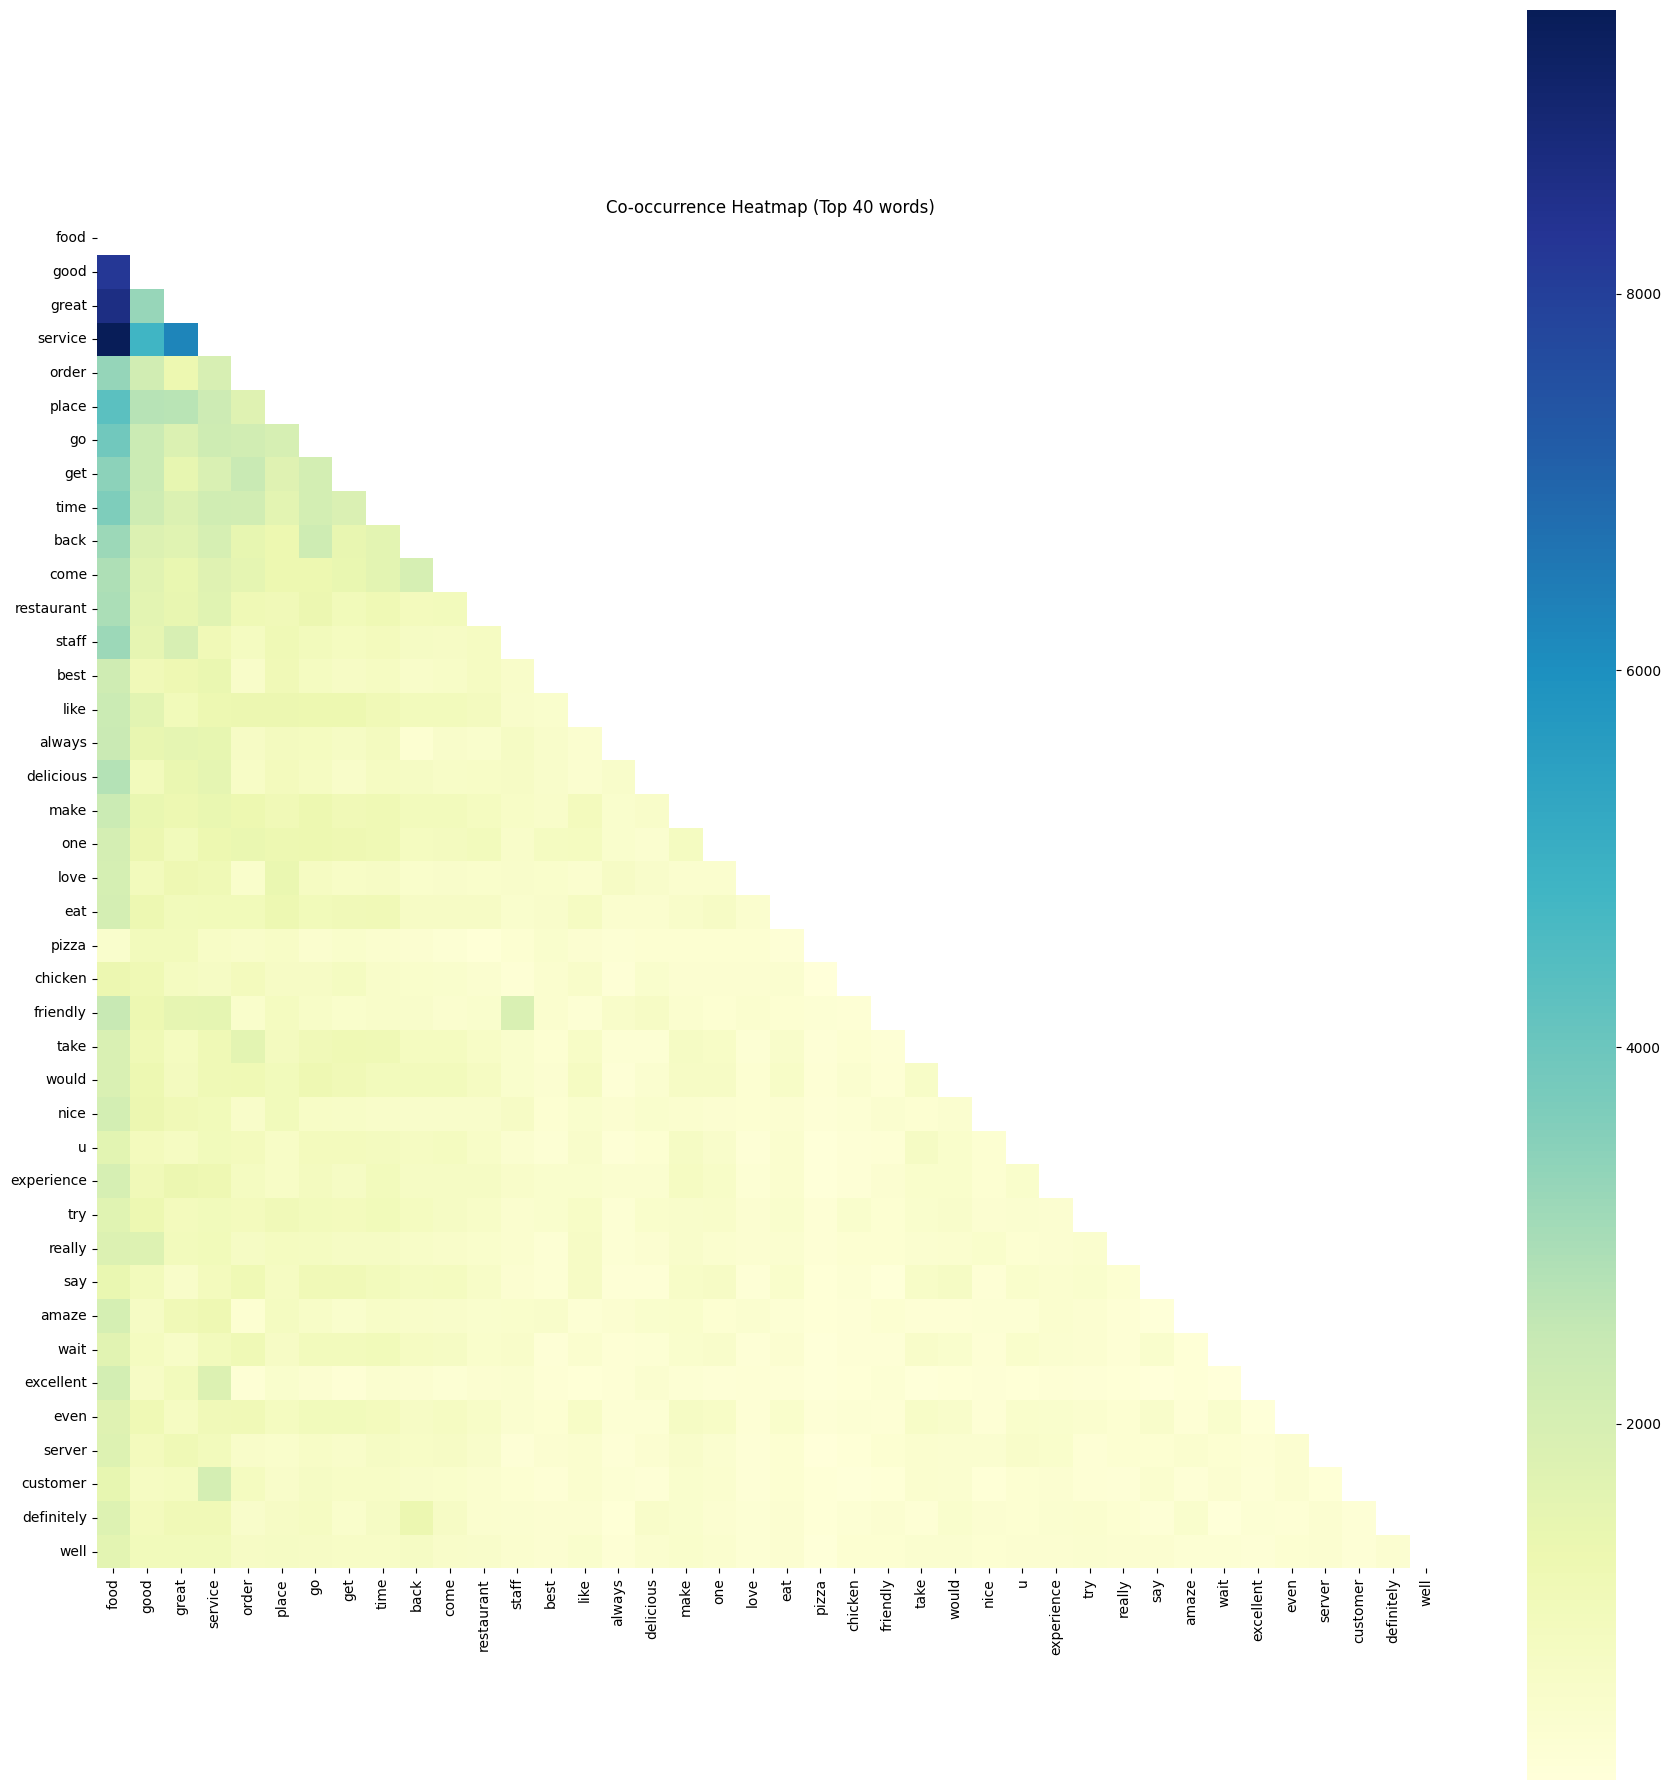

In [116]:

plot_cooccurrence_heatmap(cooc_df, top_n=40)


In [136]:
boring_words = {
    "good", "great", "place", "time", "get", "go", "make", "take", "come", "one",
    "nice", "really", "very", "always", "staff", "service", "food", "restaurant",
    "back", "order", "would", "could", "like", "best"
}

filtered_df = cooc_df.drop(index=boring_words, columns=boring_words, errors='ignore')


In [140]:
def remove_isolated_nodes(df, min_weight):
    keep = df.columns[(df > min_weight).sum(axis=1) > 0]
    return df.loc[keep, keep]

final_df = remove_isolated_nodes(filtered_df, min_weight=80)


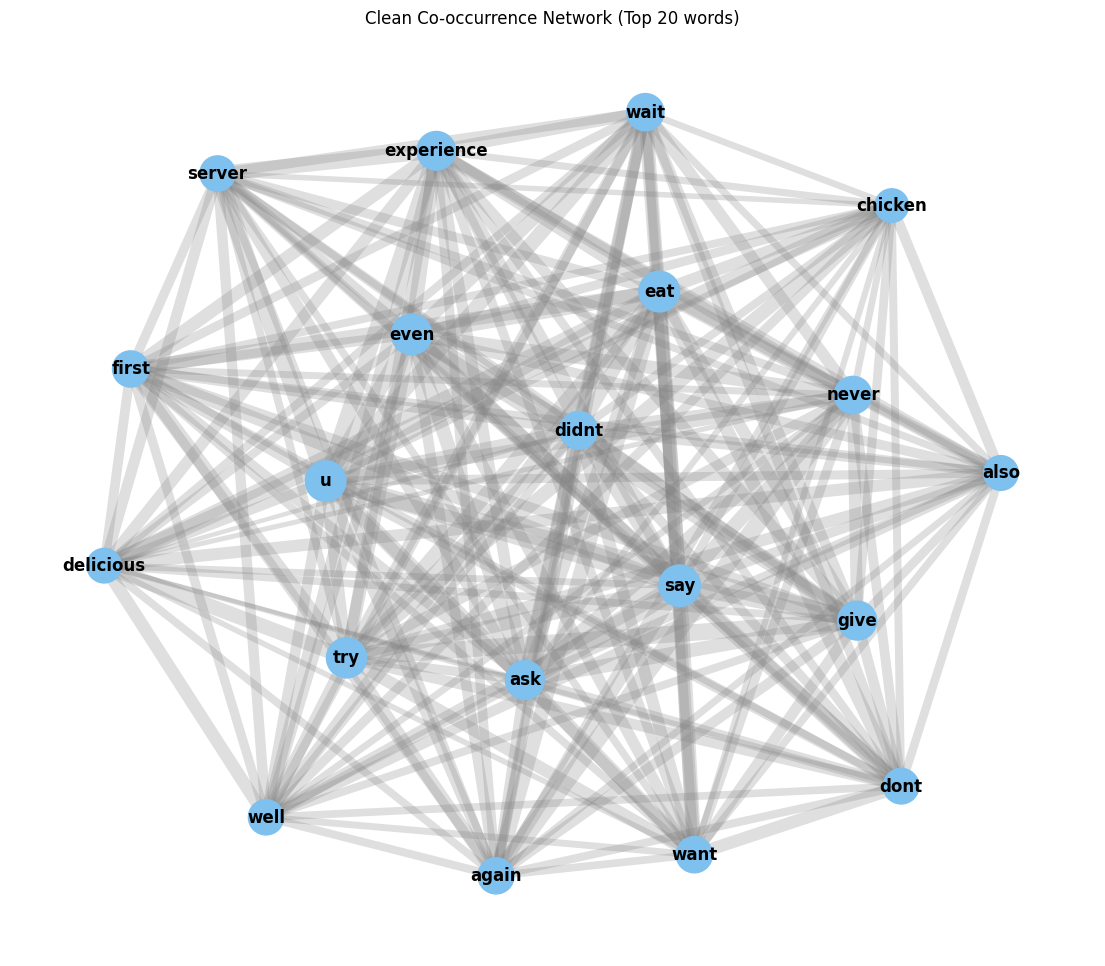

In [150]:
plot_cooccurrence_network(final_df, top_n=20, min_weight=120)
